In [1]:
# =============================================================================
# CELL 1: IMPORTS FOR SEQUENTIAL MODELS
# =============================================================================

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import math
import random
from collections import Counter

# For BLEU, we'll write a simple version manually to avoid extra libraries.
# In a real project, you might use: from nltk.translate.bleu_score import sentence_bleu

In [2]:
# =============================================================================
# CELL 2: OUR TINY TEXT CORPUS
# =============================================================================

# We use a short, repetitive sentence so the pattern is learnable even with a tiny model.
text = ("in deep learning we learn deep representations for learning . "
        "deep learning is representation learning . "
        "we represent data for learning deep features .")

print("Our text:")
print(text)
print(f"\nLength: {len(text)} characters")

# The vocabulary = every unique character
chars = sorted(list(set(text)))
vocab_size = len(chars)

print(f"\nVocabulary ({vocab_size} characters):")
print(chars)

# Mappings: char -> number, number -> char
char2idx = {ch: i for i, ch in enumerate(chars)}
idx2char = {i: ch for i, ch in enumerate(chars)}

# Encode the entire text as a list of integers
encoded = [char2idx[ch] for ch in text]
print(f"\nEncoded text (first 20): {encoded[:20]}")

Our text:
in deep learning we learn deep representations for learning . deep learning is representation learning . we represent data for learning deep features .

Length: 151 characters

Vocabulary (17 characters):
[' ', '.', 'a', 'd', 'e', 'f', 'g', 'i', 'l', 'n', 'o', 'p', 'r', 's', 't', 'u', 'w']

Encoded text (first 20): [7, 9, 0, 3, 4, 4, 11, 0, 8, 4, 2, 12, 9, 7, 9, 6, 0, 16, 4, 0]


In [3]:
# =============================================================================
# CELL 3: CREATING INPUT/TARGET PAIRS
# =============================================================================

# We will chop the text into chunks of length 'seq_length'.
# For each chunk:
#   Input = characters 0 to seq_length-1
#   Target = characters 1 to seq_length   (shifted by one)

seq_length = 20  # How many characters the model sees at once

def create_sequences(encoded_text, seq_length):
    inputs = []
    targets = []
    for i in range(len(encoded_text) - seq_length):
        inputs.append(encoded_text[i : i + seq_length])
        targets.append(encoded_text[i + 1 : i + seq_length + 1])
    return torch.tensor(inputs), torch.tensor(targets)

X_seq, y_seq = create_sequences(encoded, seq_length)

print(f"Number of sequences: {len(X_seq)}")
print(f"Input shape: {X_seq.shape}")   # [num_sequences, seq_length]
print(f"Target shape: {y_seq.shape}")  # Same shape

# Let's decode one example to see what the model learns from:
print("\nExample sequence:")
print("Input:  ", ''.join([idx2char[i.item()] for i in X_seq[0]]))
print("Target: ", ''.join([idx2char[i.item()] for i in y_seq[0]]))
# Notice: target is just input shifted left by one character.

Number of sequences: 131
Input shape: torch.Size([131, 20])
Target shape: torch.Size([131, 20])

Example sequence:
Input:   in deep learning we 
Target:  n deep learning we l


In [4]:
# =============================================================================
# CELL 4: PYTORCH DATASET AND DATALOADER
# =============================================================================

class CharDataset(Dataset):
    def __init__(self, inputs, targets):
        self.inputs = inputs
        self.targets = targets

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        return self.inputs[idx], self.targets[idx]

dataset = CharDataset(X_seq, y_seq)
dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

# Check one batch
batch_x, batch_y = next(iter(dataloader))
print(f"Batch X shape: {batch_x.shape}")  # [8, 20]
print(f"Batch Y shape: {batch_y.shape}")  # [8, 20]

Batch X shape: torch.Size([8, 20])
Batch Y shape: torch.Size([8, 20])


In [5]:
# =============================================================================
# CELL 5: EMBEDDING EXPLANATION
# =============================================================================

# An Embedding layer is simply a lookup table.
# Imagine a big matrix of shape [vocab_size, embedding_dim].
# Row 0 = vector for character 'a'
# Row 1 = vector for character 'b'
# etc.

# When you input integer 5, the embedding layer returns row 5 of the matrix.
# This is MUCH better than one-hot encoding (which would give a vector of
# length 30 with a single 1 and rest 0s). The embedding learns meaning.

embedding_dim = 16  # Each character becomes a 16-dimensional vector

embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embedding_dim)

# Test: take the first batch
embedded = embedding(batch_x)
print(f"Embedded shape: {embedded.shape}")
# [8, 20, 16] = batch_size, sequence_length, embedding_dimension

Embedded shape: torch.Size([8, 20, 16])


In [6]:
# =============================================================================
# CELL 6: SIMPLE RNN MODEL FOR NEXT-CHARACTER PREDICTION
# =============================================================================

class SimpleRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super(SimpleRNN, self).__init__()

        self.hidden_dim = hidden_dim

        # Lookup table: character index -> dense vector
        self.embedding = nn.Embedding(vocab_size, embed_dim)

        # The RNN core: processes the sequence step by step
        # batch_first=True means input shape is (batch, seq, features)
        self.rnn = nn.RNN(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )
        # PyTorch's nn.RNN implements the exact equation from the synthesis.
        # It handles the time loop internally.

        # Output layer: hidden state -> vocabulary scores
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden):
        # x shape: [batch, seq_length]
        # hidden shape: [1, batch, hidden_dim] (1 layer, batch size, hidden size)

        embedded = self.embedding(x)           # [batch, seq, embed_dim]
        out, hidden = self.rnn(embedded, hidden)
        # out: [batch, seq, hidden_dim] — hidden state at EVERY time step
        # hidden: [1, batch, hidden_dim] — hidden state at LAST time step

        # We want to predict the next character at EVERY position,
        # so we apply the linear layer to all time steps at once.
        logits = self.fc(out)                  # [batch, seq, vocab_size]

        return logits, hidden

    def init_hidden(self, batch_size, device):
        # At the very beginning, memory is blank (all zeros)
        return torch.zeros(1, batch_size, self.hidden_dim).to(device)


# Create model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
rnn_model = SimpleRNN(vocab_size, embed_dim=16, hidden_dim=32).to(device)

print("Simple RNN created.")
print(f"Number of parameters: {sum(p.numel() for p in rnn_model.parameters()):,}")

Simple RNN created.
Number of parameters: 2,433


In [7]:
# =============================================================================
# CELL 7: TRAINING LOOP FOR RNN (with Gradient Clipping)
# =============================================================================

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(rnn_model.parameters(), lr=0.005)
num_epochs = 100

rnn_losses = []

for epoch in range(num_epochs):
    rnn_model.train()
    epoch_loss = 0
    num_batches = 0

    for batch_x, batch_y in dataloader:
        batch_x = batch_x.to(device)   # [8, 20]
        batch_y = batch_y.to(device)   # [8, 20]

        batch_size_curr = batch_x.size(0)
        hidden = rnn_model.init_hidden(batch_size_curr, device)

        optimizer.zero_grad()

        # Forward pass
        logits, hidden = rnn_model(batch_x, hidden)
        # logits: [8, 20, vocab_size]

        # Compute loss
        # CrossEntropy expects: (N, C) and (N). We flatten both.
        loss = criterion(logits.reshape(-1, vocab_size), batch_y.reshape(-1))

        # Backward pass (BPTT happens automatically here!)
        loss.backward()

        # GRADIENT CLIPPING (your professor requires this)
        # Without this, RNN gradients often explode.
        torch.nn.utils.clip_grad_norm_(rnn_model.parameters(), max_norm=1.0)
        # "If the total length of the gradient vector exceeds 1.0, scale it down."

        optimizer.step()

        epoch_loss += loss.item()
        num_batches += 1

    avg_loss = epoch_loss / num_batches
    rnn_losses.append(avg_loss)

    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

print("\nRNN training complete.")

Epoch [20/100], Loss: 0.1848
Epoch [40/100], Loss: 0.1670
Epoch [60/100], Loss: 0.1533
Epoch [80/100], Loss: 0.1495
Epoch [100/100], Loss: 0.1466

RNN training complete.


In [8]:
# =============================================================================
# CELL 8: GENERATION (Inference) — See what the RNN learned
# =============================================================================

def generate_text(model, start_str, predict_len=100, temperature=1.0):
    model.eval()

    # Encode the starting string
    input_eval = torch.tensor([char2idx[ch] for ch in start_str]).unsqueeze(0).to(device)
    # shape: [1, len(start_str)]

    hidden = model.init_hidden(1, device)

    # Prime the hidden state by feeding the start string
    with torch.no_grad():
        for i in range(len(start_str) - 1):
            _, hidden = model(input_eval[:, i:i+1], hidden)

        # Now the last character of start_str is the input for next prediction
        inp = input_eval[:, -1:]

        predicted = start_str

        for _ in range(predict_len):
            logits, hidden = model(inp, hidden)
            # logits: [1, 1, vocab_size]

            # Temperature sampling: divide logits by temperature before softmax
            # Low temperature (0.5) = conservative, high (1.5) = random
            logits = logits.squeeze() / temperature
            probs = F.softmax(logits, dim=0)

            # Pick next character
            next_idx = torch.multinomial(probs, 1).item()
            predicted_char = idx2char[next_idx]
            predicted += predicted_char

            # Feed this character back as next input (auto-regressive!)
            inp = torch.tensor([[next_idx]]).to(device)

    return predicted

# Try it
generated = generate_text(rnn_model, start_str="deep ", predict_len=50)
print("RNN generated:")
print(generated)

RNN generated:
deep learning we learn deep representatnons for learnin


In [9]:
# =============================================================================
# CELL 9: LSTM MODEL
# =============================================================================

class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super(LSTMModel, self).__init__()
        self.hidden_dim = hidden_dim

        self.embedding = nn.Embedding(vocab_size, embed_dim)

        # nn.LSTM implements the exact equations from your synthesis sheet
        # It returns: outputs, (hidden_state, cell_state)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden):
        # hidden is a tuple: (h_0, c_0)
        embedded = self.embedding(x)              # [batch, seq, embed]
        out, hidden = self.lstm(embedded, hidden) # out: [batch, seq, hidden]
        logits = self.fc(out)                     # [batch, seq, vocab]
        return logits, hidden

    def init_hidden(self, batch_size, device):
        h = torch.zeros(1, batch_size, self.hidden_dim).to(device)
        c = torch.zeros(1, batch_size, self.hidden_dim).to(device)
        return (h, c)  # LSTM needs TWO states: hidden and cell

lstm_model = LSTMModel(vocab_size, embed_dim=16, hidden_dim=32).to(device)
print("LSTM created.")

LSTM created.


In [10]:
# =============================================================================
# CELL 10: TRAINING LSTM
# =============================================================================

optimizer_lstm = torch.optim.Adam(lstm_model.parameters(), lr=0.005)
lstm_losses = []

for epoch in range(num_epochs):
    lstm_model.train()
    epoch_loss = 0
    num_batches = 0

    for batch_x, batch_y in dataloader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        hidden = lstm_model.init_hidden(batch_x.size(0), device)
        optimizer_lstm.zero_grad()

        logits, hidden = lstm_model(batch_x, hidden)
        loss = criterion(logits.reshape(-1, vocab_size), batch_y.reshape(-1))

        loss.backward()
        torch.nn.utils.clip_grad_norm_(lstm_model.parameters(), max_norm=1.0)
        optimizer_lstm.step()

        epoch_loss += loss.item()
        num_batches += 1

    avg_loss = epoch_loss / num_batches
    lstm_losses.append(avg_loss)

    if (epoch + 1) % 20 == 0:
        print(f"LSTM Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

print("\nLSTM training complete.")

LSTM Epoch [20/100], Loss: 0.1873
LSTM Epoch [40/100], Loss: 0.1619
LSTM Epoch [60/100], Loss: 0.1501
LSTM Epoch [80/100], Loss: 0.1490
LSTM Epoch [100/100], Loss: 0.1445

LSTM training complete.


In [11]:
# =============================================================================
# CELL 11: GRU MODEL
# =============================================================================

class GRUModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super(GRUModel, self).__init__()
        self.hidden_dim = hidden_dim

        self.embedding = nn.Embedding(vocab_size, embed_dim)

        # nn.GRU: only returns hidden state (no separate cell state)
        self.gru = nn.GRU(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden):
        embedded = self.embedding(x)
        out, hidden = self.gru(embedded, hidden)
        logits = self.fc(out)
        return logits, hidden

    def init_hidden(self, batch_size, device):
        return torch.zeros(1, batch_size, self.hidden_dim).to(device)

gru_model = GRUModel(vocab_size, embed_dim=16, hidden_dim=32).to(device)
print("GRU created.")

GRU created.


In [12]:
# =============================================================================
# CELL 12: TRAINING GRU
# =============================================================================

optimizer_gru = torch.optim.Adam(gru_model.parameters(), lr=0.005)
gru_losses = []

for epoch in range(num_epochs):
    gru_model.train()
    epoch_loss = 0
    num_batches = 0

    for batch_x, batch_y in dataloader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        hidden = gru_model.init_hidden(batch_x.size(0), device)
        optimizer_gru.zero_grad()

        logits, hidden = gru_model(batch_x, hidden)
        loss = criterion(logits.reshape(-1, vocab_size), batch_y.reshape(-1))

        loss.backward()
        torch.nn.utils.clip_grad_norm_(gru_model.parameters(), max_norm=1.0)
        optimizer_gru.step()

        epoch_loss += loss.item()
        num_batches += 1

    avg_loss = epoch_loss / num_batches
    gru_losses.append(avg_loss)

    if (epoch + 1) % 20 == 0:
        print(f"GRU Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

print("\nGRU training complete.")

GRU Epoch [20/100], Loss: 0.1840
GRU Epoch [40/100], Loss: 0.1613
GRU Epoch [60/100], Loss: 0.1528
GRU Epoch [80/100], Loss: 0.1425
GRU Epoch [100/100], Loss: 0.1390

GRU training complete.


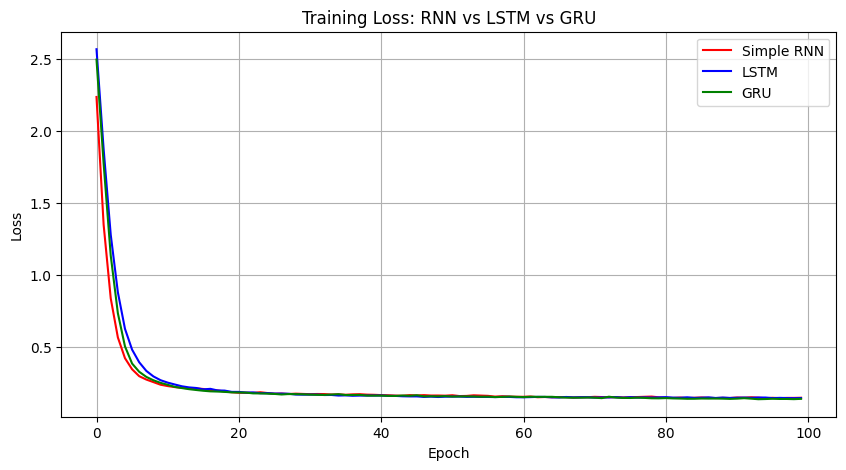

=== GENERATION COMPARISON ===
RNN:   deep reprd eepresentations for learning deep 
LSTM:  deep learning we learn deep representations f
GRU:   deep representation learning . we represent d


In [13]:
# =============================================================================
# CELL 13: COMPARISON PLOT
# =============================================================================

plt.figure(figsize=(10, 5))
plt.plot(rnn_losses, label='Simple RNN', color='red')
plt.plot(lstm_losses, label='LSTM', color='blue')
plt.plot(gru_losses, label='GRU', color='green')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss: RNN vs LSTM vs GRU')
plt.legend()
plt.grid(True)
plt.show()

# Generate text from all three to compare memory
print("=== GENERATION COMPARISON ===")
print("RNN:  ", generate_text(rnn_model, "deep ", 40))
print("LSTM: ", generate_text(lstm_model, "deep ", 40))
print("GRU:  ", generate_text(gru_model, "deep ", 40))

In [14]:
# =============================================================================
# CELL 14: GRADIENT CLIPPING EXPERIMENT
# =============================================================================

def train_one_epoch_no_clipping(model, dataloader, device):
    """Train one epoch WITHOUT clipping. Returns max gradient norm observed."""
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)  # High LR to stress it
    max_grad_norm = 0

    for batch_x, batch_y in dataloader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        hidden = model.init_hidden(batch_x.size(0), device)

        optimizer.zero_grad()
        logits, hidden = model(batch_x, hidden)
        loss = criterion(logits.reshape(-1, vocab_size), batch_y.reshape(-1))
        loss.backward()

        # Measure gradient norm
        total_norm = 0
        for p in model.parameters():
            if p.grad is not None:
                total_norm += p.grad.data.norm(2).item() ** 2
        total_norm = total_norm ** 0.5
        max_grad_norm = max(max_grad_norm, total_norm)

        optimizer.step()
        break  # Just one batch for demo

    return max_grad_norm, loss.item()

# Fresh RNN
rnn_fresh = SimpleRNN(vocab_size, 16, 32).to(device)
norm_no_clip, loss_no_clip = train_one_epoch_no_clipping(rnn_fresh, dataloader, device)

# Fresh RNN with clipping
rnn_fresh2 = SimpleRNN(vocab_size, 16, 32).to(device)
optimizer_temp = torch.optim.Adam(rnn_fresh2.parameters(), lr=0.01)
for batch_x, batch_y in dataloader:
    batch_x = batch_x.to(device)
    batch_y = batch_y.to(device)
    hidden = rnn_fresh2.init_hidden(batch_x.size(0), device)
    optimizer_temp.zero_grad()
    logits, hidden = rnn_fresh2(batch_x, hidden)
    loss = criterion(logits.reshape(-1, vocab_size), batch_y.reshape(-1))
    loss.backward()
    torch.nn.utils.clip_grad_norm_(rnn_fresh2.parameters(), max_norm=1.0)

    # Measure after clipping
    total_norm = 0
    for p in rnn_fresh2.parameters():
        if p.grad is not None:
            total_norm += p.grad.data.norm(2).item() ** 2
    total_norm = total_norm ** 0.5
    norm_clip = total_norm
    loss_clip = loss.item()
    break

print(f"Without clipping: Max grad norm = {norm_no_clip:.2f}, Loss = {loss_no_clip:.4f}")
print(f"With clipping:    Max grad norm = {norm_clip:.2f}, Loss = {loss_clip:.4f}")
print("\nObservation: Clipping caps the gradient magnitude, preventing explosion.")

Without clipping: Max grad norm = 0.59, Loss = 2.8585
With clipping:    Max grad norm = 0.71, Loss = 2.8579

Observation: Clipping caps the gradient magnitude, preventing explosion.


In [15]:
# =============================================================================
# CELL 15: PARALLEL CORPUS FOR TRANSLATION (French -> English)
# =============================================================================

# A tiny synthetic corpus. In your real project, replace with Tatoeba or similar.
src_sentences = [  # French (source)
    "je suis étudiant",
    "tu es professeur",
    "il aime le deep learning",
    "nous apprenons pytorch",
    "elle est ingénieure",
    "le chat dort",
    "nous aimons les séquences",
    "je programme en python"
]

tgt_sentences = [  # English (target)
    "i am a student",
    "you are a professor",
    "he loves deep learning",
    "we learn pytorch",
    "she is an engineer",
    "the cat sleeps",
    "we love sequences",
    "i program in python"
]

print("Source (French):", len(src_sentences), "sentences")
print("Target (English):", len(tgt_sentences), "sentences")

Source (French): 8 sentences
Target (English): 8 sentences


In [16]:
# =============================================================================
# CELL 16: DATA PREPARATION PIPELINE
# =============================================================================

# Special tokens (from your synthesis sheet)
PAD_TOKEN = "<pad>"
BOS_TOKEN = "<bos>"
EOS_TOKEN = "<eos>"
UNK_TOKEN = "<unk>"

def tokenize(sentence):
    return sentence.lower().split()

# Build vocabularies
src_tokens = [tokenize(s) for s in src_sentences]
tgt_tokens = [tokenize(s) for s in tgt_sentences]

# Collect all unique words
src_vocab = [PAD_TOKEN, BOS_TOKEN, EOS_TOKEN, UNK_TOKEN] + sorted(list(set(w for sent in src_tokens for w in sent)))
tgt_vocab = [PAD_TOKEN, BOS_TOKEN, EOS_TOKEN, UNK_TOKEN] + sorted(list(set(w for sent in tgt_tokens for w in sent)))

src_word2idx = {w: i for i, w in enumerate(src_vocab)}
tgt_word2idx = {w: i for i, w in enumerate(tgt_vocab)}
src_idx2word = {i: w for w, i in src_word2idx.items()}
tgt_idx2word = {i: w for w, i in tgt_word2idx.items()}

print(f"Source vocab size: {len(src_vocab)}")
print(f"Target vocab size: {len(tgt_vocab)}")

# Numericalize
def encode(sentence_tokens, vocab, add_special=True):
    indices = []
    if add_special:
        indices.append(vocab[BOS_TOKEN])
    for w in sentence_tokens:
        indices.append(vocab.get(w, vocab[UNK_TOKEN]))
    if add_special:
        indices.append(vocab[EOS_TOKEN])
    return indices

src_encoded = [encode(s, src_word2idx) for s in src_tokens]
tgt_encoded = [encode(s, tgt_word2idx) for s in tgt_tokens]

# Example
print("\nExample encoding:")
print("French:", src_encoded[0], "->", [src_idx2word[i] for i in src_encoded[0]])
print("English:", tgt_encoded[0], "->", [tgt_idx2word[i] for i in tgt_encoded[0]])

Source vocab size: 29
Target vocab size: 30

Example encoding:
French: [1, 16, 25, 28, 2] -> ['<bos>', 'je', 'suis', 'étudiant', '<eos>']
English: [1, 12, 5, 4, 26, 2] -> ['<bos>', 'i', 'am', 'a', 'student', '<eos>']


In [17]:
# =============================================================================
# CELL 17: PADDING AND MASKING
# =============================================================================

def pad_sequences(sequences, pad_idx):
    """Pad all sequences to the length of the longest one."""
    max_len = max(len(s) for s in sequences)
    padded = []
    for s in sequences:
        s = s + [pad_idx] * (max_len - len(s))
        padded.append(s)
    return torch.tensor(padded)

src_pad_idx = src_word2idx[PAD_TOKEN]
tgt_pad_idx = tgt_word2idx[PAD_TOKEN]

src_tensor = pad_sequences(src_encoded, src_pad_idx)
tgt_tensor = pad_sequences(tgt_encoded, tgt_pad_idx)

print("Source tensor shape:", src_tensor.shape)
print("Target tensor shape:", tgt_tensor.shape)

# Mask: 1 for real tokens, 0 for padding
def create_mask(tensor, pad_idx):
    return (tensor != pad_idx).long()

src_mask = create_mask(src_tensor, src_pad_idx)
tgt_mask = create_mask(tgt_tensor, tgt_pad_idx)

print("\nSource mask (first sentence):")
print(src_mask[0])
print("Target mask (first sentence):")
print(tgt_mask[0])

Source tensor shape: torch.Size([8, 7])
Target tensor shape: torch.Size([8, 6])

Source mask (first sentence):
tensor([1, 1, 1, 1, 1, 0, 0])
Target mask (first sentence):
tensor([1, 1, 1, 1, 1, 1])


In [18]:
# =============================================================================
# CELL 18: ENCODER
# =============================================================================

class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super(Encoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=src_word2idx[PAD_TOKEN])
        # padding_idx tells embedding: "don't learn anything for <pad>, keep it zero"

        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        # We use GRU for the encoder. Could be LSTM too.

    def forward(self, src):
        # src: [batch, src_len]
        embedded = self.embedding(src)          # [batch, src_len, embed_dim]
        outputs, hidden = self.gru(embedded)    # outputs: [batch, src_len, hidden]
                                                # hidden: [1, batch, hidden]
        return outputs, hidden

# Test
enc_test = Encoder(len(src_vocab), embed_dim=16, hidden_dim=32).to(device)
src_batch = src_tensor[:2].to(device)
enc_out, enc_hidden = enc_test(src_batch)
print(f"Encoder output shape: {enc_out.shape}")    # [2, src_len, 32]
print(f"Encoder hidden shape: {enc_hidden.shape}")   # [1, 2, 32]

Encoder output shape: torch.Size([2, 7, 32])
Encoder hidden shape: torch.Size([1, 2, 32])


In [19]:
# =============================================================================
# CELL 19: DECODER
# =============================================================================

class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super(Decoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=tgt_word2idx[PAD_TOKEN])

        # Input to GRU = embedding of current token + maybe context (simplified here)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)

        # Map hidden state to vocabulary scores
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, input_token, hidden):
        # input_token: [batch, 1] — one token per sentence in the batch
        # hidden: [1, batch, hidden_dim]

        embedded = self.embedding(input_token)   # [batch, 1, embed_dim]
        output, hidden = self.gru(embedded, hidden)  # output: [batch, 1, hidden]
        prediction = self.fc(output.squeeze(1))        # [batch, vocab_size]

        return prediction, hidden

In [20]:
# =============================================================================
# CELL 20: SEQ2SEQ MODEL + TEACHER FORCING
# =============================================================================

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super(Seq2Seq, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, tgt, teacher_forcing_ratio=0.5):
        # src: [batch, src_len]
        # tgt: [batch, tgt_len]

        batch_size = src.size(0)
        tgt_len = tgt.size(1)
        tgt_vocab_size = len(tgt_vocab)

        # Tensor to store all decoder outputs
        outputs = torch.zeros(batch_size, tgt_len, tgt_vocab_size).to(self.device)

        # Encode source sentence
        _, hidden = self.encoder(src)
        # hidden: [1, batch, hidden_dim] — this is the context vector!

        # First input to decoder is <bos>
        input_token = tgt[:, 0].unsqueeze(1)  # [batch, 1]
        # Actually, teacher forcing usually starts with <bos> from target.

        for t in range(1, tgt_len):
            prediction, hidden = self.decoder(input_token, hidden)
            outputs[:, t, :] = prediction

            # Teacher forcing: coin flip
            teacher_force = random.random() < teacher_forcing_ratio

            # Next input is either true target token or predicted token
            if teacher_force:
                input_token = tgt[:, t].unsqueeze(1)  # True token
            else:
                top1 = prediction.argmax(1)           # Predicted token
                input_token = top1.unsqueeze(1)

        return outputs

# Create full model
encoder = Encoder(len(src_vocab), embed_dim=16, hidden_dim=32).to(device)
decoder = Decoder(len(tgt_vocab), embed_dim=16, hidden_dim=32).to(device)
seq2seq = Seq2Seq(encoder, decoder, device).to(device)

print("Seq2Seq model created.")

Seq2Seq model created.


In [21]:
# =============================================================================
# CELL 21: MASKED LOSS (Ignore <pad> positions)
# =============================================================================

def masked_cross_entropy(logits, target, mask):
    """
    logits: [batch, tgt_len, tgt_vocab]
    target: [batch, tgt_len]
    mask: [batch, tgt_len] — 1 for real tokens, 0 for pad
    """
    # Flatten everything
    logits_flat = logits.view(-1, logits.size(-1))    # [batch*tgt_len, vocab]
    target_flat = target.view(-1)                     # [batch*tgt_len]
    mask_flat = mask.view(-1).float()                 # [batch*tgt_len]

    # Compute loss for every token, even pads (we'll mask after)
    losses = F.cross_entropy(logits_flat, target_flat, reduction='none')
    # losses: [batch*tgt_len] — loss per token

    # Apply mask: zero out losses for pad tokens
    masked_losses = losses * mask_flat

    # Average only over real tokens
    return masked_losses.sum() / mask_flat.sum()

In [22]:
# =============================================================================
# CELL 22: TRAINING THE TRANSLATION MODEL
# =============================================================================

optimizer_s2s = torch.optim.Adam(seq2seq.parameters(), lr=0.01)
num_epochs_s2s = 200

src_batch = src_tensor.to(device)
tgt_batch = tgt_tensor.to(device)
tgt_mask_batch = create_mask(tgt_tensor, tgt_pad_idx).to(device)

seq2seq.train()
for epoch in range(num_epochs_s2s):
    optimizer_s2s.zero_grad()

    # Forward with teacher forcing (high ratio for stable learning)
    outputs = seq2seq(src_batch, tgt_batch, teacher_forcing_ratio=0.8)
    # outputs: [8, tgt_len, tgt_vocab]

    loss = masked_cross_entropy(outputs, tgt_batch, tgt_mask_batch)

    loss.backward()
    torch.nn.utils.clip_grad_norm_(seq2seq.parameters(), max_norm=1.0)
    optimizer_s2s.step()

    if (epoch + 1) % 40 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs_s2s}], Loss: {loss.item():.4f}")

print("\nSeq2Seq training complete.")

Epoch [40/200], Loss: 0.7143
Epoch [80/200], Loss: 0.6131
Epoch [120/200], Loss: 0.6090
Epoch [160/200], Loss: 0.6076
Epoch [200/200], Loss: 0.6068

Seq2Seq training complete.


In [23]:
# =============================================================================
# CELL 23: GREEDY DECODING
# =============================================================================

def greedy_decode(model, src_sentence, max_len=20):
    model.eval()

    # Encode source
    src_tokens = tokenize(src_sentence)
    src_indices = [src_word2idx.get(w, src_word2idx[UNK_TOKEN]) for w in src_tokens]
    src_indices = [src_word2idx[BOS_TOKEN]] + src_indices + [src_word2idx[EOS_TOKEN]]
    src_tensor_in = torch.tensor([src_indices]).to(device)

    with torch.no_grad():
        _, hidden = model.encoder(src_tensor_in)

    # Start with <bos>
    tgt_indices = [tgt_word2idx[BOS_TOKEN]]

    for _ in range(max_len):
        input_token = torch.tensor([[tgt_indices[-1]]]).to(device)

        with torch.no_grad():
            prediction, hidden = model.decoder(input_token, hidden)

        next_token = prediction.argmax(1).item()
        tgt_indices.append(next_token)

        if next_token == tgt_word2idx[EOS_TOKEN]:
            break

    # Convert indices to words
    words = [tgt_idx2word[i] for i in tgt_indices]
    return ' '.join(words)

# Test on training sentences
print("=== GREEDY TRANSLATION ===")
for i in range(len(src_sentences)):
    src = src_sentences[i]
    translation = greedy_decode(seq2seq, src)
    print(f"FR: {src}")
    print(f"EN: {translation}")
    print(f"Real: {tgt_sentences[i]}")
    print()

=== GREEDY TRANSLATION ===
FR: je suis étudiant
EN: <bos> i am a student <eos>
Real: i am a student

FR: tu es professeur
EN: <bos> you are a professor <eos>
Real: you are a professor

FR: il aime le deep learning
EN: <bos> he loves deep learning <eos>
Real: he loves deep learning

FR: nous apprenons pytorch
EN: <bos> we learn pytorch <eos>
Real: we learn pytorch

FR: elle est ingénieure
EN: <bos> she is an engineer <eos>
Real: she is an engineer

FR: le chat dort
EN: <bos> the cat sleeps <eos>
Real: the cat sleeps

FR: nous aimons les séquences
EN: <bos> we love sequences <eos>
Real: we love sequences

FR: je programme en python
EN: <bos> i program in python <eos>
Real: i program in python



In [24]:
# =============================================================================
# CELL 24: BEAM SEARCH
# =============================================================================

def beam_search_decode(model, src_sentence, beam_width=3, max_len=20):
    model.eval()

    # Encode
    src_tokens = tokenize(src_sentence)
    src_indices = [src_word2idx.get(w, src_word2idx[UNK_TOKEN]) for w in src_tokens]
    src_indices = [src_word2idx[BOS_TOKEN]] + src_indices + [src_word2idx[EOS_TOKEN]]
    src_tensor_in = torch.tensor([src_indices]).to(device)

    with torch.no_grad():
        _, hidden = model.encoder(src_tensor_in)

    # Each beam item: (log_prob, sequence_of_indices, hidden_state)
    # Start with <bos>
    bos_idx = tgt_word2idx[BOS_TOKEN]
    beams = [(0.0, [bos_idx], hidden)]

    for _ in range(max_len):
        candidates = []

        for log_prob, seq, h in beams:
            if seq[-1] == tgt_word2idx[EOS_TOKEN]:
                candidates.append((log_prob, seq, h))
                continue

            input_token = torch.tensor([[seq[-1]]]).to(device)
            with torch.no_grad():
                pred, new_h = model.decoder(input_token, h)

            # Get top k probabilities
            log_probs = F.log_softmax(pred, dim=1)  # [1, vocab]
            topk_log_probs, topk_indices = torch.topk(log_probs, beam_width)

            for i in range(beam_width):
                new_log_prob = log_prob + topk_log_probs[0, i].item()
                new_seq = seq + [topk_indices[0, i].item()]
                candidates.append((new_log_prob, new_seq, new_h))

        # Keep top beam_width candidates
        candidates.sort(key=lambda x: x[0], reverse=True)
        beams = candidates[:beam_width]

        # If all beams ended with EOS, stop
        if all(b[1][-1] == tgt_word2idx[EOS_TOKEN] for b in beams):
            break

    # Return the best sequence
    best_seq = beams[0][1]
    words = [tgt_idx2word[i] for i in best_seq]
    return ' '.join(words)

# Compare greedy vs beam
test_sentence = "je suis étudiant"
print("Greedy:", greedy_decode(seq2seq, test_sentence))
print("Beam:  ", beam_search_decode(seq2seq, test_sentence, beam_width=3))

Greedy: <bos> i am a student <eos>
Beam:   <bos> i am a student <eos>


In [25]:
# =============================================================================
# CELL 25: SIMPLE BLEU SCORE
# =============================================================================

def get_ngrams(tokens, n):
    return [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]

def bleu_score(candidate, reference, max_n=4):
    """
    Very simplified BLEU for educational purposes.
    Real BLEU also has a brevity penalty.
    """
    candidate_tokens = tokenize(candidate)
    reference_tokens = tokenize(reference)

    if len(candidate_tokens) == 0:
        return 0.0

    scores = []
    for n in range(1, max_n + 1):
        cand_ngrams = get_ngrams(candidate_tokens, n)
        ref_ngrams = get_ngrams(reference_tokens, n)

        if len(cand_ngrams) == 0:
            continue

        matches = sum(1 for ng in cand_ngrams if ng in ref_ngrams)
        precision = matches / len(cand_ngrams)
        scores.append(precision)

    # Geometric mean of precisions
    if len(scores) == 0:
        return 0.0

    log_scores = [math.log(s) if s > 0 else -999 for s in scores]
    avg_log = sum(log_scores) / len(log_scores)

    # Brevity penalty (simplified)
    bp = 1.0 if len(candidate_tokens) > len(reference_tokens) else math.exp(1 - len(reference_tokens)/len(candidate_tokens))

    return bp * math.exp(avg_log)

# Evaluate greedy translations
print("=== BLEU SCORES (Greedy) ===")
for i in range(len(src_sentences)):
    pred = greedy_decode(seq2seq, src_sentences[i])
    ref = tgt_sentences[i]
    score = bleu_score(pred, ref)
    print(f"{src_sentences[i]} -> BLEU: {score:.4f}")

=== BLEU SCORES (Greedy) ===
je suis étudiant -> BLEU: 0.5081
tu es professeur -> BLEU: 0.5081
il aime le deep learning -> BLEU: 0.5081
nous apprenons pytorch -> BLEU: 0.0000
elle est ingénieure -> BLEU: 0.5081
le chat dort -> BLEU: 0.0000
nous aimons les séquences -> BLEU: 0.0000
je programme en python -> BLEU: 0.5081


In [26]:
# =============================================================================
# CELL 26: SUMMARY TABLE (For your report)
# =============================================================================

print("""
=== COMPARISON OF SEQUENTIAL ARCHITECTURES ===

| Model    | Memory Mechanism          | Parameters | Long-term Memory | Speed  | Best For               |
|----------|---------------------------|------------|------------------|--------|------------------------|
| RNN      | Single hidden state       | Low        | Poor (vanishing) | Fast   | Baseline, short seq    |
| LSTM     | Cell state + 3 gates      | High       | Excellent        | Slow   | Long dependencies      |
| GRU      | Hidden state + 2 gates    | Medium     | Good             | Medium | Good compromise        |
| Seq2Seq  | Encoder + Decoder         | High       | Context vector   | Medium | Translation, generation  |

=== KEY CONCEPTS CHECKLIST ===
✓ Chain rule factorization: P(y|x) = product of conditionals
✓ Perplexity: exp(-average log probability)
✓ BPTT: unrolling in time, gradient flow through steps
✓ Gradient clipping: prevents explosion
✓ Teacher forcing: feed true token during training
✓ Auto-regressive inference: feed own prediction at test time
✓ Greedy: argmax each step
✓ Beam search: keep k best partial hypotheses
✓ BLEU: n-gram precision for translation quality
""")


=== COMPARISON OF SEQUENTIAL ARCHITECTURES ===

| Model    | Memory Mechanism          | Parameters | Long-term Memory | Speed  | Best For               |
|----------|---------------------------|------------|------------------|--------|------------------------|
| RNN      | Single hidden state       | Low        | Poor (vanishing) | Fast   | Baseline, short seq    |
| LSTM     | Cell state + 3 gates      | High       | Excellent        | Slow   | Long dependencies      |
| GRU      | Hidden state + 2 gates    | Medium     | Good             | Medium | Good compromise        |
| Seq2Seq  | Encoder + Decoder         | High       | Context vector   | Medium | Translation, generation  |

=== KEY CONCEPTS CHECKLIST ===
✓ Chain rule factorization: P(y|x) = product of conditionals
✓ Perplexity: exp(-average log probability)
✓ BPTT: unrolling in time, gradient flow through steps
✓ Gradient clipping: prevents explosion
✓ Teacher forcing: feed true token during training
✓ Auto-regressive infere